# Прогнозирование временных рядов (Bybit): единый Jupyter pipeline

Этот ноутбук переносит текущее решение в воспроизводимый формат:
- загрузка данных BTC/ETH с основного Bybit,
- очистка и предобработка,
- запуск моделей Naive / ARIMA,
- проверки, визуализация и экспорт результатов.

## 1) Подготовка окружения и зависимостей

Если чего-то не хватает, раскомментируй установку в ячейке ниже и перезапусти kernel.

In [43]:
# При необходимости установки (раскомментируй):
# %pip install pandas numpy requests statsmodels matplotlib seaborn torch

import sys
print('Python:', sys.version)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


## 2) Импорт модулей и базовые настройки

Задаём импорты, параметры отображения и конфигурацию загрузки данных.

In [45]:
from __future__ import annotations

import importlib
import pandas as pd
import seaborn as sns
from pathlib import Path

from data_pipeline import DataConfig, DataProcessor, fetch_klines, build_datasets
import model_baselines as _mb
from export_utils import plot_result, export_all_results

# В ноутбуке иногда остаётся старый кэш модуля после правок файла — принудительно обновляем
_mb = importlib.reload(_mb)
run_naive = _mb.run_naive
run_arima = _mb.run_arima
run_sarima = _mb.run_sarima
run_nbeats = _mb.run_nbeats
run_lstm = _mb.run_lstm
run_lstm_grid_search = _mb.run_lstm_grid_search
run_lstm_chunked_cv_search = _mb.run_lstm_chunked_cv_search
run_lstm_chunked_cv_pipeline = _mb.run_lstm_chunked_cv_pipeline
run_lstm_gridsearchcv_native_pipeline = _mb.run_lstm_gridsearchcv_native_pipeline
run_naive_gridsearchcv_native_pipeline = _mb.run_naive_gridsearchcv_native_pipeline
run_arima_gridsearchcv_native_pipeline = _mb.run_arima_gridsearchcv_native_pipeline
run_sarima_gridsearchcv_native_pipeline = _mb.run_sarima_gridsearchcv_native_pipeline
run_nbeats_gridsearchcv_native_pipeline = _mb.run_nbeats_gridsearchcv_native_pipeline

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='60',
    bars=1000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']
OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3) Загрузка входных данных/файлов

Скачиваем свечи с Bybit API и проверяем структуру.

In [46]:
raw_data = {}
for symbol in SYMBOLS:
    raw_data[symbol] = fetch_klines(symbol, CONFIG)
    print(f"{symbol}: {len(raw_data[symbol])} rows")

raw_data['BTCUSDT'].head()

BTCUSDT: 1000 rows
ETHUSDT: 1000 rows


,timestamp,open,high,low,close,volume,turnover
0,2026-01-24 00:00:00+00:00,89551.7,89589.6,89375.0,89401.1,428.594,3.834372e+07
1,2026-01-24 01:00:00+00:00,89401.1,89538.5,89400.0,89500.0,264.519,2.366783e+07
2,2026-01-24 02:00:00+00:00,89500.0,89671.3,89500.0,89659.9,464.867,4.165208e+07
3,2026-01-24 03:00:00+00:00,89659.9,89883.4,89620.0,89724.4,637.066,5.719778e+07
4,2026-01-24 04:00:00+00:00,89724.4,89800.0,89662.8,89791.6,434.017,3.893477e+07


## 4) Очистка и предобработка данных

Убираем некорректные значения, нули и экстремальные выбросы по лог-доходности.

In [47]:
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f"{symbol}: before={rep['initial_rows']} after={rep['final_rows']} removed={rep['removed_total']} "
        f"(zero/nonpos={rep['removed_nonpositive_or_zero']}, outliers={rep['removed_outliers']})"
    )

cleaned_data['BTCUSDT'].head()

BTCUSDT: before=1000 after=1000 removed=0 (zero/nonpos=0, outliers=0)
ETHUSDT: before=1000 after=1000 removed=0 (zero/nonpos=0, outliers=0)


,timestamp,open,high,low,close,volume,turnover
0,2026-01-24 00:00:00+00:00,89551.7,89589.6,89375.0,89401.1,428.594,3.834372e+07
1,2026-01-24 01:00:00+00:00,89401.1,89538.5,89400.0,89500.0,264.519,2.366783e+07
2,2026-01-24 02:00:00+00:00,89500.0,89671.3,89500.0,89659.9,464.867,4.165208e+07
3,2026-01-24 03:00:00+00:00,89659.9,89883.4,89620.0,89724.4,637.066,5.719778e+07
4,2026-01-24 04:00:00+00:00,89724.4,89800.0,89662.8,89791.6,434.017,3.893477e+07


## 5) Основная логика (функции и вычисления)

Разбиваем данные на train/test и реализуем запуск моделей.

In [48]:
datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f"{symbol}: full={len(data['full'])} train={len(data['train'])} test={len(data['test'])}")

BTCUSDT: full=1000 train=800 test=200
ETHUSDT: full=1000 train=800 test=200


## 6) Проверка результата и отладочные проверки

Быстрые assert-проверки целостности данных и базового запуска.

In [49]:
for symbol in SYMBOLS:
    assert symbol in datasets, f'{symbol} отсутствует в datasets'
    assert len(datasets[symbol]['train']) > 10, f'{symbol}: слишком мало train данных'
    assert len(datasets[symbol]['test']) > 10, f'{symbol}: слишком мало test данных'
    assert (datasets[symbol]['full'] > 0).all(), f'{symbol}: есть неположительные значения после очистки'

print('Базовые проверки данных пройдены.')

# smoke-test на Naive
smoke_symbol = 'BTCUSDT'
smoke_metrics, smoke_pred = run_naive(datasets[smoke_symbol]['train'], datasets[smoke_symbol]['test'])
print('Smoke Naive metrics:', smoke_metrics)
smoke_pred.head()

Базовые проверки данных пройдены.
Smoke Naive metrics: {'MAE': 334.8995, 'RMSE': 473.64471637504795, 'MAPE': 0.4925341708784264}


,y_true,y_pred
0,67926.5,67805.5
1,68554.2,67926.5
2,68267.0,68554.2
3,68016.2,68267.0
4,68140.4,68016.2


## 7) Визуализация результатов

Строим график исходного ряда и сравнение факта/прогноза для выбранной модели.

In [50]:
# 1) Начальные данные
RUN_SYMBOL = 'BTCUSDT'  # BTCUSDT или ETHUSDT
ARIMA_ORDER = (1, 1, 1)
SARIMA_ORDER = (1, 1, 0)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 24)

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

ALL_RESULTS = {}

print(f'Готово к запуску моделей для {RUN_SYMBOL}')

Готово к запуску моделей для BTCUSDT


NAIVE GridSearchCV: train_points=800 | test_points=200 | n_splits=4
Fitting 4 folds for each of 1 candidates, totalling 4 fits
NAIVE split info: {'full_points': 1000, 'train_points': 800, 'test_points': 200, 'test_ratio': 0.2, 'cv_n_splits': 4}
NAIVE best params: {'strategy': 'last'}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_strategy,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.0,0.0,0.000522,0.000005,last,{'strategy': 'last'},-495.661875,-385.76,-234.87875,-237.298125,-338.399688,109.444627,1,338.399688,109.444627


SYMBOL=BTCUSDT | MODEL=naive
Metrics: {'MAE': 335.51, 'RMSE': 474.1168134542369, 'MAPE': 0.4934175655398458}


,y_true,y_pred
0,67926.5,67805.5
1,68554.2,67926.5
2,68267.0,68554.2
3,68016.2,68267.0
4,68140.4,68016.2


,y_true,y_pred
195,70183.7,70506.8
196,69895.1,70183.7
197,69182.8,69895.1
198,68373.6,69182.8
199,68801.1,68373.6


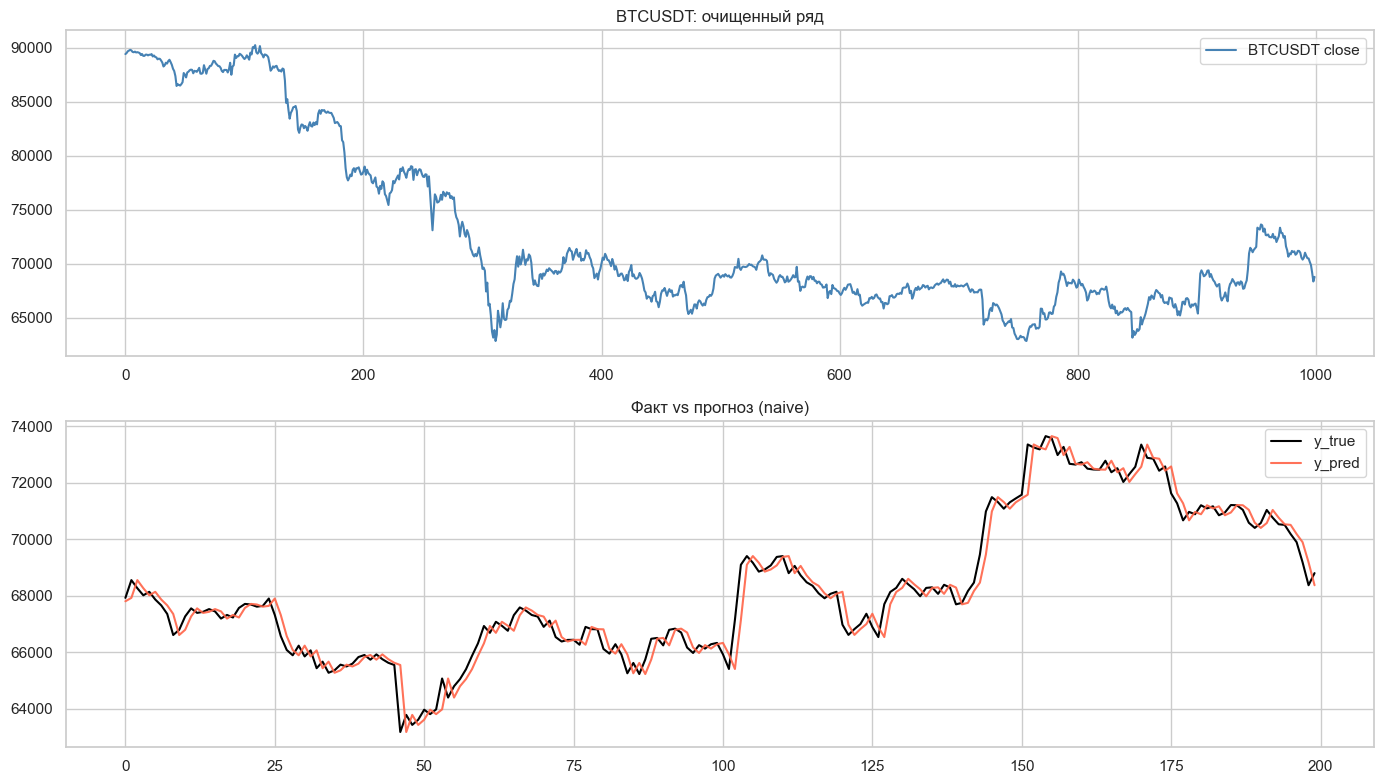

In [ ]:
# 2) Модель Naive + native GridSearchCV
RUN_MODEL = 'naive'

NAIVE_PARAM_GRID = {
    'strategy': ['last'],
}
NAIVE_CV_SPLITS = 4

naive_best_params, naive_cv_df, model_metrics, pred_df, naive_split_info = run_naive_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=NAIVE_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=NAIVE_CV_SPLITS,
    scoring='MAE',
    n_jobs=166,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print('NAIVE split info:', naive_split_info)
print('NAIVE best params:', naive_best_params)
display(naive_cv_df.head(20))
print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

ARIMA GridSearchCV: train_points=800 | test_points=200 | n_splits=4
Fitting 4 folds for each of 9 candidates, totalling 36 fits
ARIMA GridSearchCV: best MAE=338.399687 | order=(0, 1, 0), refit_every=24
ARIMA: 0%
ARIMA: 5%
ARIMA: 10%
ARIMA: 15%
ARIMA: 20%
ARIMA: 25%
ARIMA: 30%
ARIMA: 35%
ARIMA: 40%
ARIMA: 45%
ARIMA: 50%
ARIMA: 55%
ARIMA: 60%
ARIMA: 65%
ARIMA: 70%
ARIMA: 75%
ARIMA: 80%
ARIMA: 85%
ARIMA: 90%
ARIMA: 95%
ARIMA: 100%
ARIMA split info: {'full_points': 1000, 'train_points': 800, 'test_points': 200, 'test_ratio': 0.2, 'cv_n_splits': 4}
ARIMA best params: {'d': 1, 'p': 0, 'q': 0, 'refit_every': 24}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_d,param_p,param_q,param_refit_every,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000250,0.000433,0.353253,0.050655,1,0,0,24,"{'d': 1, 'p': 0, 'q': 0, 'refit_every': 24}",-495.661875,-385.760000,-234.878750,-237.298125,-338.399687,109.444627,1,338.399687,109.444627
1,0.000000,0.000000,0.412994,0.065066,1,0,1,24,"{'d': 1, 'p': 0, 'q': 1, 'refit_every': 24}",-497.973129,-386.110817,-234.865807,-237.001720,-338.987868,110.385080,2,338.987868,110.385080
2,0.000000,0.000000,0.355700,0.052885,1,1,0,24,"{'d': 1, 'p': 1, 'q': 0, 'refit_every': 24}",-498.340781,-386.082432,-234.866926,-237.021153,-339.077823,110.509726,3,339.077823,110.509726
3,0.000376,0.000650,0.452135,0.093273,1,0,2,24,"{'d': 1, 'p': 0, 'q': 2, 'refit_every': 24}",-498.140828,-386.302381,-234.810960,-237.162701,-339.104218,110.441689,4,339.104218,110.441689
4,0.000000,0.000000,0.552973,0.120474,1,1,2,24,"{'d': 1, 'p': 1, 'q': 2, 'refit_every': 24}",-498.609026,-386.261754,-234.829816,-237.132467,-339.208266,110.608502,5,339.208266,110.608502
5,0.000000,0.000000,0.421267,0.090657,1,2,0,24,"{'d': 1, 'p': 2, 'q': 0, 'refit_every': 24}",-498.226238,-386.722755,-234.830502,-237.159002,-339.234624,110.513697,6,339.234624,110.513697
6,0.000000,0.000000,0.677427,0.130908,1,2,2,24,"{'d': 1, 'p': 2, 'q': 2, 'refit_every': 24}",-505.616739,-396.859433,-234.976190,-236.981728,-343.608522,114.294115,7,343.608522,114.294115
7,0.000251,0.000435,0.533522,0.107621,1,1,1,24,"{'d': 1, 'p': 1, 'q': 1, 'refit_every': 24}",-497.585285,-386.162943,-235.061453,-603.220035,-430.507429,136.468537,8,430.507429,136.468537
8,0.000250,0.000433,0.587746,0.111914,1,2,1,24,"{'d': 1, 'p': 2, 'q': 1, 'refit_every': 24}",-723.837325,-425.018653,-19904.586837,-4383.641652,-6359.271116,7974.210871,9,6359.271116,7974.210871


SYMBOL=BTCUSDT | MODEL=arima
Metrics: {'MAE': 335.51000000000056, 'RMSE': 474.1168134542367, 'MAPE': 0.4934175655398467}


,y_true,y_pred
0,67926.5,67805.5
1,68554.2,67926.5
2,68267.0,68554.2
3,68016.2,68267.0
4,68140.4,68016.2


,y_true,y_pred
195,70183.7,70506.8
196,69895.1,70183.7
197,69182.8,69895.1
198,68373.6,69182.8
199,68801.1,68373.6


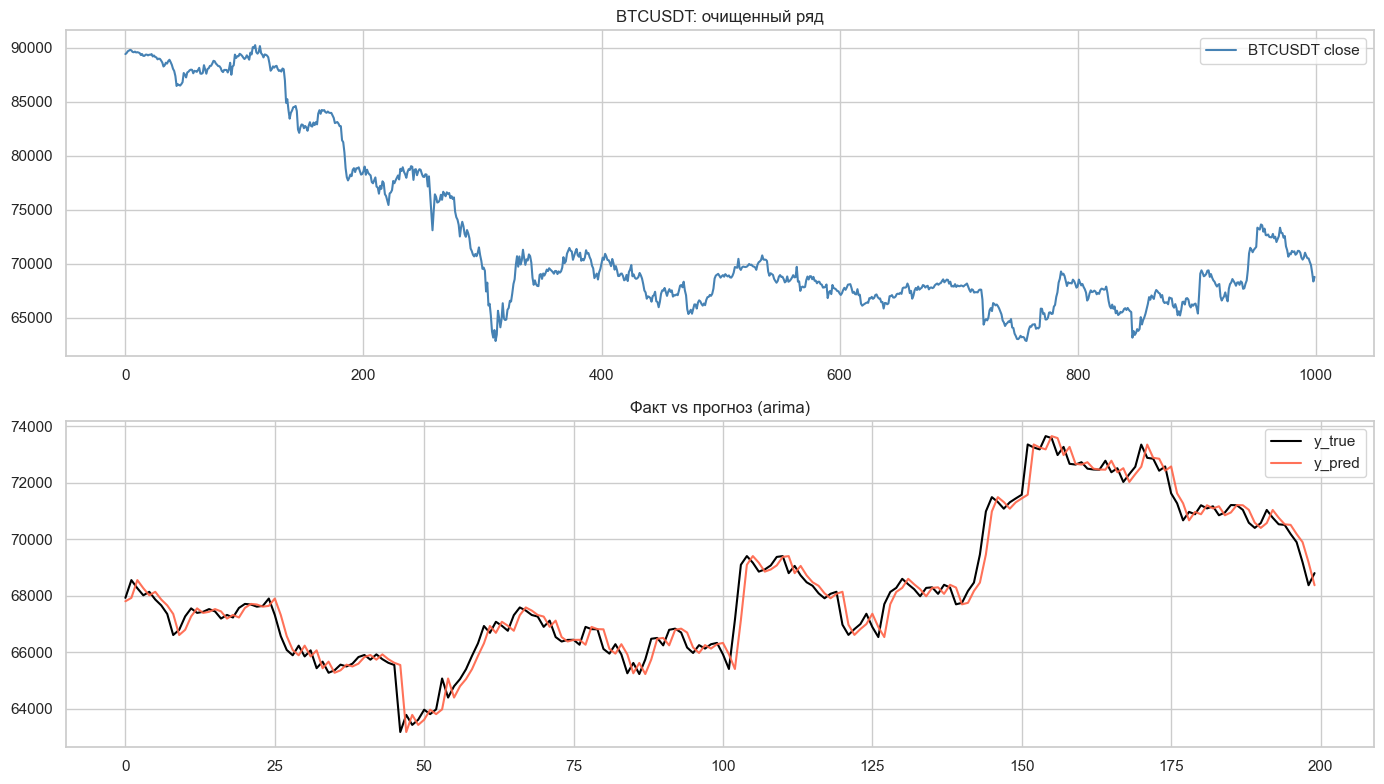

In [39]:
# 3) Модель ARIMA + native GridSearchCV
RUN_MODEL = 'arima'

ARIMA_PARAM_GRID = {
    'p': [0, 1, 2],
    'd': [1],
    'q': [0, 1, 2],
    'refit_every': [24],
}
ARIMA_CV_SPLITS = 4

arima_best_params, arima_cv_df, model_metrics, pred_df, arima_split_info = run_arima_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=ARIMA_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=ARIMA_CV_SPLITS,
    scoring='MAE',
    n_jobs=1,
)

ARIMA_ORDER = (
    int(arima_best_params['p']),
    int(arima_best_params['d']),
    int(arima_best_params['q']),
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print('ARIMA split info:', arima_split_info)
print('ARIMA best params:', arima_best_params)
display(arima_cv_df.head(20))
print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

SARIMA GridSearchCV: train_points=800 | test_points=200 | n_splits=3
Fitting 3 folds for each of 4 candidates, totalling 12 fits
SARIMA GridSearchCV: best MAE=365.574504 | order=(1, 1, 1), seasonal=(1, 1, 1, 24)
SARIMA: 0%
SARIMA: 5%
SARIMA: 10%
SARIMA: 15%
SARIMA: 20%
SARIMA: 25%
SARIMA: 30%
SARIMA: 35%
SARIMA: 40%
SARIMA: 45%
SARIMA: 50%
SARIMA: 55%
SARIMA: 60%
SARIMA: 65%
SARIMA: 70%
SARIMA: 75%
SARIMA: 80%
SARIMA: 85%
SARIMA: 90%
SARIMA: 95%
SARIMA: 100%
SARIMA: 100%
SARIMA split info: {'full_points': 1000, 'train_points': 800, 'test_points': 200, 'test_ratio': 0.2, 'cv_n_splits': 3}
SARIMA best params: {'d': 1, 'fit_window': 1000, 'maxiter': 50, 'p': 1, 'q': 1, 'refit_every': 48, 's': 24, 'sd': 1, 'sp': 1, 'sq': 1}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_d,param_fit_window,param_maxiter,param_p,param_q,param_refit_every,param_s,param_sd,param_sp,param_sq,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000335,0.000474,31.535661,11.360776,1,1000,50,1,1,48,24,1,1,1,"{'d': 1, 'fit_window': 1000, 'maxiter': 50, 'p...",-552.090892,-296.391102,-248.241518,-365.574504,133.343836,1,365.574504,133.343836
1,0.000168,0.000237,25.038134,8.701472,1,1000,50,1,0,48,24,1,1,1,"{'d': 1, 'fit_window': 1000, 'maxiter': 50, 'p...",-553.346155,-297.113755,-248.409338,-366.289749,133.755011,2,366.289749,133.755011
2,0.000335,0.000474,17.559039,5.760551,1,1000,50,1,1,48,24,1,1,0,"{'d': 1, 'fit_window': 1000, 'maxiter': 50, 'p...",-647.577259,-353.202858,-294.332252,-431.704123,154.525824,3,431.704123,154.525824
3,0.000335,0.000474,15.426006,5.513066,1,1000,50,1,0,48,24,1,1,0,"{'d': 1, 'fit_window': 1000, 'maxiter': 50, 'p...",-653.875453,-352.417066,-295.183985,-433.825501,157.343345,4,433.825501,157.343345


SYMBOL=BTCUSDT | MODEL=sarima
Metrics: {'MAE': 336.30946372218546, 'RMSE': 474.30920867495814, 'MAPE': 0.49477514629204133}


,y_true,y_pred
0,67926.5,67853.720433
1,68554.2,67993.989625
2,68267.0,68469.197362
3,68016.2,68318.069814
4,68140.4,68043.272170


,y_true,y_pred
195,70183.7,70481.418256
196,69895.1,70187.438958
197,69182.8,69830.921190
198,68373.6,69092.163520
199,68801.1,68508.940709


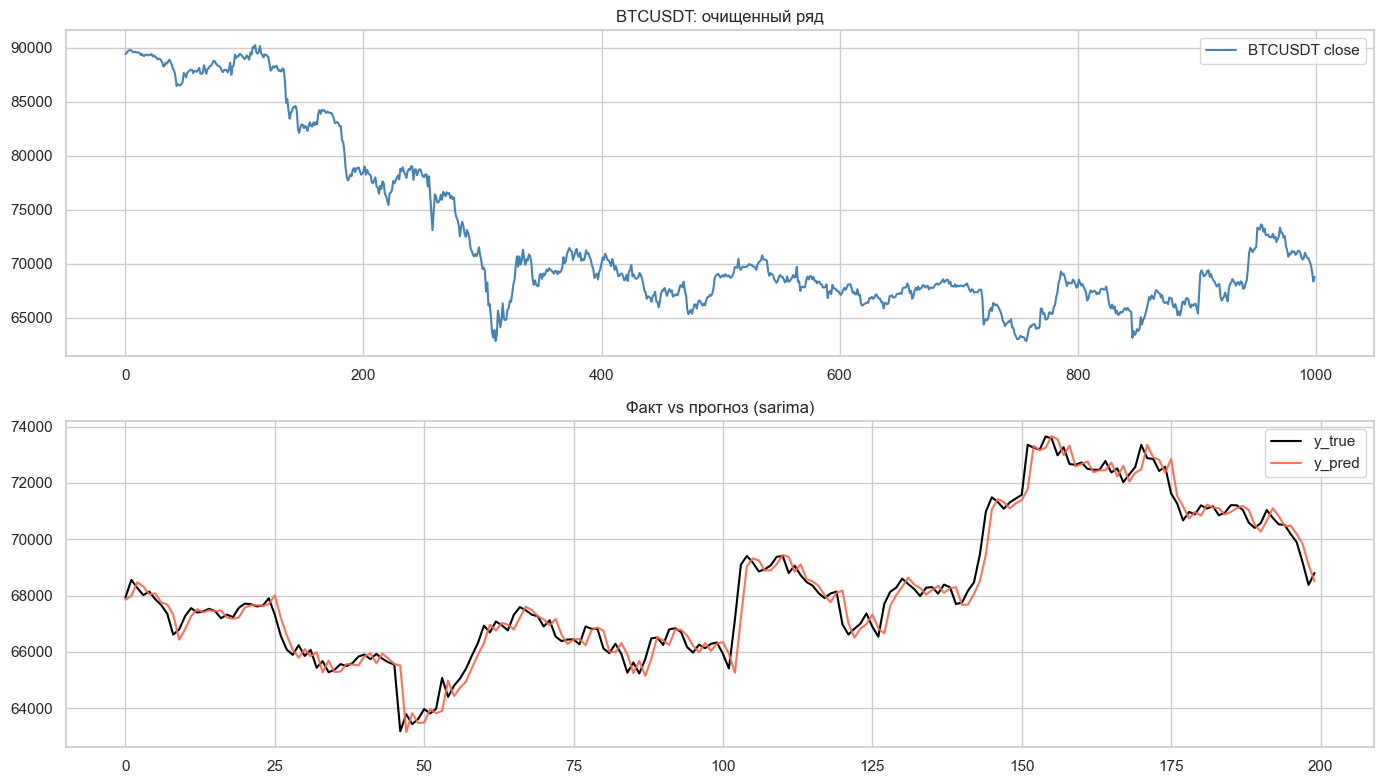

In [42]:
# 3.2) Модель SARIMA + native GridSearchCV
RUN_MODEL = 'sarima'

SARIMA_PARAM_GRID = {
    'p': [1],
    'd': [1],
    'q': [0, 1],
    'sp': [1],
    'sd': [1],
    'sq': [0, 1],
    's': [24],
    'refit_every': [48],
    'fit_window': [1000],
    'maxiter': [50],
}
SARIMA_CV_SPLITS = 3

sarima_best_params, sarima_cv_df, model_metrics, pred_df, sarima_split_info = run_sarima_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=SARIMA_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=SARIMA_CV_SPLITS,
    scoring='MAE',
    n_jobs=32,
)

SARIMA_ORDER = (
    int(sarima_best_params['p']),
    int(sarima_best_params['d']),
    int(sarima_best_params['q']),
)
SARIMA_SEASONAL_ORDER = (
    int(sarima_best_params['sp']),
    int(sarima_best_params['sd']),
    int(sarima_best_params['sq']),
    int(sarima_best_params['s']),
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print('SARIMA split info:', sarima_split_info)
print('SARIMA best params:', sarima_best_params)
display(sarima_cv_df.head(20))
print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())

plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

AST auto-config: len(full)=1000, context_len=[72, 96, 120, 168], cv_splits=2
AST GridSearchCV: train_points=800 | test_points=200 | n_splits=2
Fitting 2 folds for each of 64 candidates, totalling 128 fits
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=196
AST: 0%
AST: 5% | lr=0.000596
AST: 10% | lr=0.000586
AST: 15% | lr=0.000568
AST: 20% | lr=0.000544
AST: 25% | lr=0.000514
AST: 30% | lr=0.000478
AST: 35% | lr=0.000439
AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=462
AST: 0%
AST: 5% |

c:\Users\zzz20\ModelLine\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


AST: 15% | lr=0.000568
AST: 20% | lr=0.000544
AST: 25% | lr=0.000514
AST: 30% | lr=0.000478
AST: 35% | lr=0.000439
AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=438
AST: 0%
AST: 5% | lr=0.000596
AST: 10% | lr=0.000586
AST: 15% | lr=0.000568
AST: 20% | lr=0.000544
AST: 25% | lr=0.000514
AST: 30% | lr=0.000478
AST: 35% | lr=0.000439
AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% 

c:\Users\zzz20\ModelLine\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=438
AST: 0%
AST: 5% | lr=0.000596
AST: 10% | lr=0.000586
AST: 15% | lr=0.000568
AST: 20% | lr=0.000544
AST: 25% | lr=0.000514
AST: 30% | lr=0.000478
AST: 35% | lr=0.000439
AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA

...

AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=366
AST: 0%
AST: 5% | lr=0.000596
AST: 10% | lr=0.000586
AST: 15% | lr=0.000568
AST: 20% | lr=0.000544
AST: 25% | lr=0.000514
AST: 30% | lr=0.000478
AST: 35% | lr=0.000439
AST: 40% | lr=0.000396
AST: 45% | lr=0.000351
AST: 50% | lr=0.000305
AST: 55% | lr=0.000259
AST: 60% | lr=0.000214
AST: 65% | lr=0.000171
AST: 70% | lr=0.000132
AST: 75% | lr=0.000096
AST: 80% | lr=0.000066
AST: 85% | lr=0.000042
AST: 90% | lr=0.000024
AST: 95% | lr=0.000014
AST: 100% | lr=0.000010
AST GridSearchCV: best MAE=572.641660 | {'batch_size': 64, 'context_len': 120, 'd_model': 96, 'd_steps': 1, 'dropout': 0.1, 'epochs': 20, 'ff_dim': 192, 'lambda_adv': 0.006, 'lr': 0.0006, 'min_lr': 1e-05, 'n_heads':

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_d_model,param_d_steps,param_dropout,param_epochs,param_ff_dim,param_lambda_adv,param_lr,param_min_lr,param_n_heads,param_n_layers,param_pred_len,param_topk,param_use_amp,param_use_gan,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000000,0.000000,1.066493,0.568770,64,120,96,1,0.10,20,192,0.006,0.0006,0.00001,8,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-264.348947,-572.641660,308.292713,1,572.641660,308.292713
1,0.000000,0.000000,1.040644,0.552351,64,120,96,1,0.10,20,192,0.008,0.0006,0.00001,8,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-264.348947,-572.641660,308.292713,1,572.641660,308.292713
2,0.000000,0.000000,0.989564,0.450524,64,120,128,1,0.10,20,192,0.006,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-273.483069,-577.208721,303.725652,3,577.208721,303.725652
3,0.000000,0.000000,1.018326,0.521597,64,120,128,1,0.10,20,192,0.008,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-273.483069,-577.208721,303.725652,3,577.208721,303.725652
4,0.000257,0.000257,0.989413,0.495133,64,120,96,1,0.10,20,192,0.006,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-293.002071,-586.968222,293.966151,5,586.968222,293.966151
5,0.000000,0.000000,0.961610,0.438589,64,120,96,1,0.10,20,192,0.008,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-293.002071,-586.968222,293.966151,5,586.968222,293.966151
6,0.000251,0.000251,0.985505,0.464964,64,120,128,1,0.10,20,192,0.006,0.0006,0.00001,8,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-297.718689,-589.326531,291.607842,7,589.326531,291.607842
7,0.000000,0.000000,1.025553,0.488360,64,120,128,1,0.10,20,192,0.008,0.0006,0.00001,8,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-880.934373,-297.718689,-589.326531,291.607842,7,589.326531,291.607842
8,0.000000,0.000000,1.000987,0.502311,64,120,96,1,0.12,20,192,0.006,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-1327.938374,-264.287683,-796.113029,531.825345,9,796.113029,531.825345
9,0.000000,0.000000,1.056907,0.516509,64,120,96,1,0.12,20,192,0.008,0.0006,0.00001,4,2,1,24,True,auto,"{'batch_size': 64, 'context_len': 120, 'd_mode...",-1327.938374,-264.287683,-796.113029,531.825345,9,796.113029,531.825345


SYMBOL=BTCUSDT | MODEL=ast
Metrics: {'MAE': 375.2567704384084, 'RMSE': 522.5359275099312, 'MAPE': 0.5505212596786673}


,y_true,y_pred
0,67926.500042,68044.169586
1,68554.200064,68047.319558
2,68266.999968,68575.741393
3,68016.199736,68504.490035
4,68140.400185,68239.026934


,y_true,y_pred
195,70183.699936,70621.792319
196,69895.100131,70356.300079
197,69182.800216,70050.290517
198,68373.599927,69418.546835
199,68679.000133,68617.418413


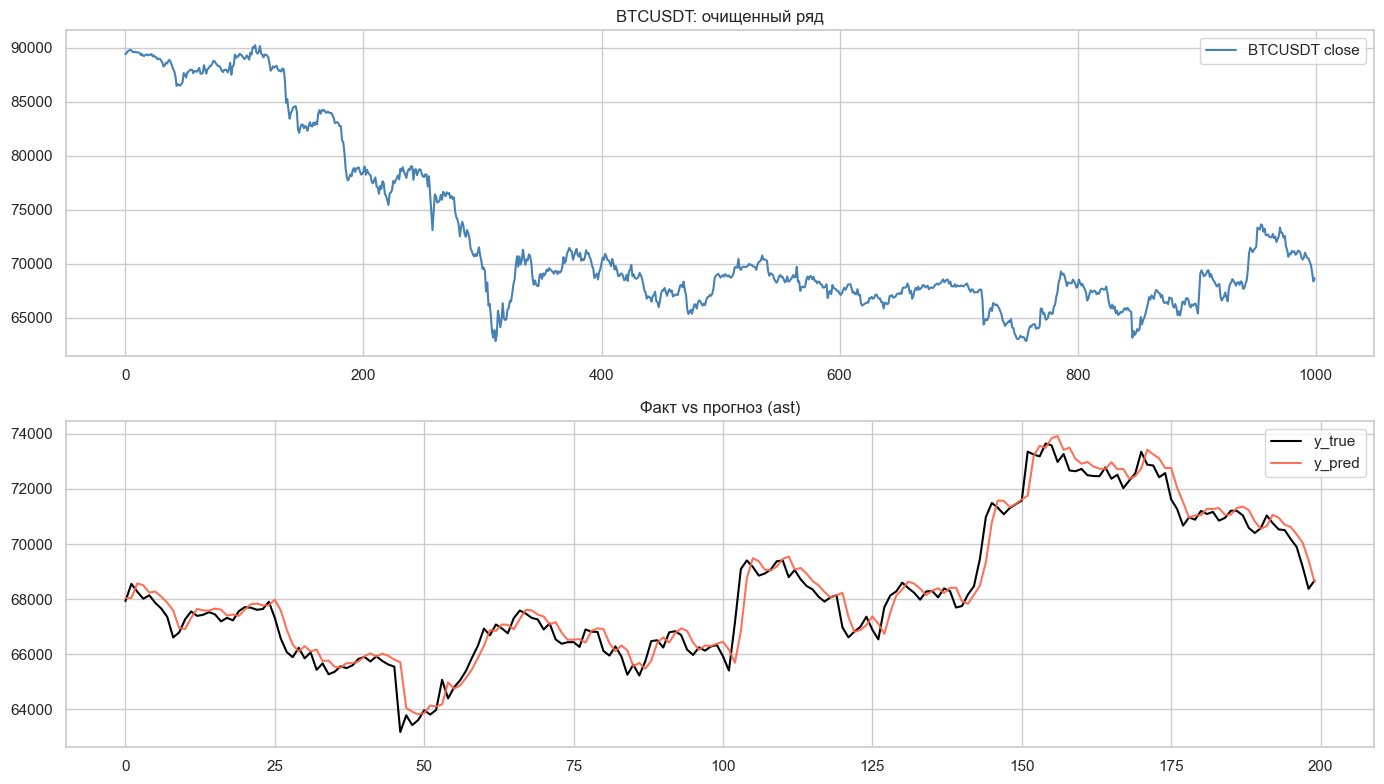

In [51]:
# 3.5) Модель AST + native GridSearchCV
from experiment_blocks import run_ast_astmain_style, run_ast_gridsearchcv_native_pipeline

RUN_MODEL = 'ast'

# Подстраиваем сетку под текущую длину ряда, чтобы не падать на коротких сериях
train_points_est = int(len(full) * (1.0 - CONFIG.test_ratio))
max_context_allowed = max(48, train_points_est - 40)
candidate_context = [72, 96, 120, 168]
ast_contexts = [c for c in candidate_context if c <= max_context_allowed]
if not ast_contexts:
    ast_contexts = [max(48, min(72, max_context_allowed))]

# Практичная сетка для AST (умеренное число комбинаций)
AST_PARAM_GRID = {
    'context_len': ast_contexts,
    'pred_len': [1],
    'epochs': [20],
    'batch_size': [64],
    'lr': [6e-4],
    'min_lr': [1e-5],
    'lambda_adv': [0.006, 0.008],
    'd_steps': [1],
    'd_model': [96, 128],
    'n_heads': [4, 8],
    'n_layers': [2],
    'ff_dim': [192],
    'dropout': [0.10, 0.12],
    'topk': [24],
    'use_amp': [True],
    'use_gan': ['auto'],
}
AST_CV_SPLITS = 3 if len(full) >= 1200 else 2

print(f'AST auto-config: len(full)={len(full)}, context_len={ast_contexts}, cv_splits={AST_CV_SPLITS}')

ast_best_params, ast_cv_df, model_metrics, pred_df, ast_split_info = run_ast_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=AST_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=AST_CV_SPLITS,
    scoring='MAE',
    use_cuda=True,
    n_jobs=1,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print('AST split info:', ast_split_info)
print('AST best params:', ast_best_params)
display(ast_cv_df.head(20))
print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

NBEATS GridSearchCV: train_points=800 | test_points=200 | n_splits=3
Fitting 3 folds for each of 64 candidates, totalling 192 fits
NBEATS GridSearchCV: best MAE=340.902388 | {'batch_size': 128, 'context_len': 120, 'epochs': 16, 'layer_size': 256, 'layers': 4, 'lr': 0.001, 'n_blocks': 4}
NBEATS device: cuda
NBEATS train: 0%
NBEATS train: 6%
NBEATS train: 12%
NBEATS train: 18%
NBEATS train: 25%
NBEATS train: 31%
NBEATS train: 37%
NBEATS train: 43%
NBEATS train: 50%
NBEATS train: 56%
NBEATS train: 62%
NBEATS train: 68%
NBEATS train: 75%
NBEATS train: 81%
NBEATS train: 87%
NBEATS train: 93%
NBEATS train: 100%
NBEATS infer: 5%
NBEATS infer: 10%
NBEATS infer: 15%
NBEATS infer: 20%
NBEATS infer: 25%
NBEATS infer: 30%
NBEATS infer: 35%
NBEATS infer: 40%
NBEATS infer: 45%
NBEATS infer: 50%
NBEATS infer: 55%
NBEATS infer: 60%
NBEATS infer: 65%
NBEATS infer: 70%
NBEATS infer: 75%
NBEATS infer: 80%
NBEATS infer: 85%
NBEATS infer: 90%
NBEATS infer: 95%
NBEATS infer: 100%
NBEATS split info: {'full_p

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_batch_size,param_context_len,param_epochs,param_layer_size,param_layers,param_lr,param_n_blocks,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score,score,score_std
0,0.000000,0.000000,0.376309,0.089370,128,120,16,256,4,0.0010,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-502.472278,-287.882228,-232.352657,-340.902388,116.474619,1,340.902388,116.474619
1,0.000000,0.000000,0.315353,0.063120,128,120,16,192,4,0.0010,3,"{'batch_size': 128, 'context_len': 120, 'epoch...",-508.884887,-291.517940,-232.080134,-344.160987,118.978109,2,344.160987,118.978109
2,0.000000,0.000000,0.383988,0.098005,128,120,24,256,4,0.0010,3,"{'batch_size': 128, 'context_len': 120, 'epoch...",-505.005720,-293.687720,-236.098809,-344.930750,115.605991,3,344.930750,115.605991
3,0.000000,0.000000,0.491424,0.137237,128,120,24,256,4,0.0010,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-506.940462,-294.071228,-234.538344,-345.183345,116.933214,4,345.183345,116.933214
4,0.000253,0.000358,0.395841,0.075150,128,120,16,192,4,0.0010,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-529.807944,-286.358234,-230.932285,-349.032821,129.814593,5,349.032821,129.814593
5,0.000335,0.000474,0.288868,0.069920,128,168,16,192,4,0.0010,3,"{'batch_size': 128, 'context_len': 168, 'epoch...",-507.358350,-296.726215,-243.335679,-349.140081,113.980708,6,349.140081,113.980708
6,0.000000,0.000000,0.360045,0.094092,128,120,16,192,3,0.0006,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-525.354879,-290.900880,-232.275152,-349.510304,126.623405,7,349.510304,126.623405
7,0.000000,0.000000,0.352967,0.078609,128,120,16,256,3,0.0010,4,"{'batch_size': 128, 'context_len': 120, 'epoch...",-508.016419,-306.445170,-238.811127,-351.090905,114.346851,8,351.090905,114.346851
8,0.000000,0.000000,0.366074,0.079408,128,168,16,256,4,0.0010,4,"{'batch_size': 128, 'context_len': 168, 'epoch...",-525.054699,-306.577993,-234.002216,-355.211636,123.698048,9,355.211636,123.698048
9,0.000667,0.000472,0.498115,0.141725,128,168,24,192,3,0.0006,4,"{'batch_size': 128, 'context_len': 168, 'epoch...",-539.273494,-298.304317,-230.760504,-356.112772,132.417092,10,356.112772,132.417092


SYMBOL=BTCUSDT | MODEL=nbeats
Metrics: {'MAE': 335.2477407417723, 'RMSE': 474.1687685346829, 'MAPE': 0.49294701182719036}


,y_true,y_pred
0,67926.5,67829.443963
1,68554.2,67950.479592
2,68267.0,68579.226014
3,68016.2,68293.240022
4,68140.4,68037.901123


,y_true,y_pred
195,70183.7,70448.270849
196,69895.1,70125.202299
197,69182.8,69834.041938
198,68373.6,69123.081883
199,68679.0,68319.714667


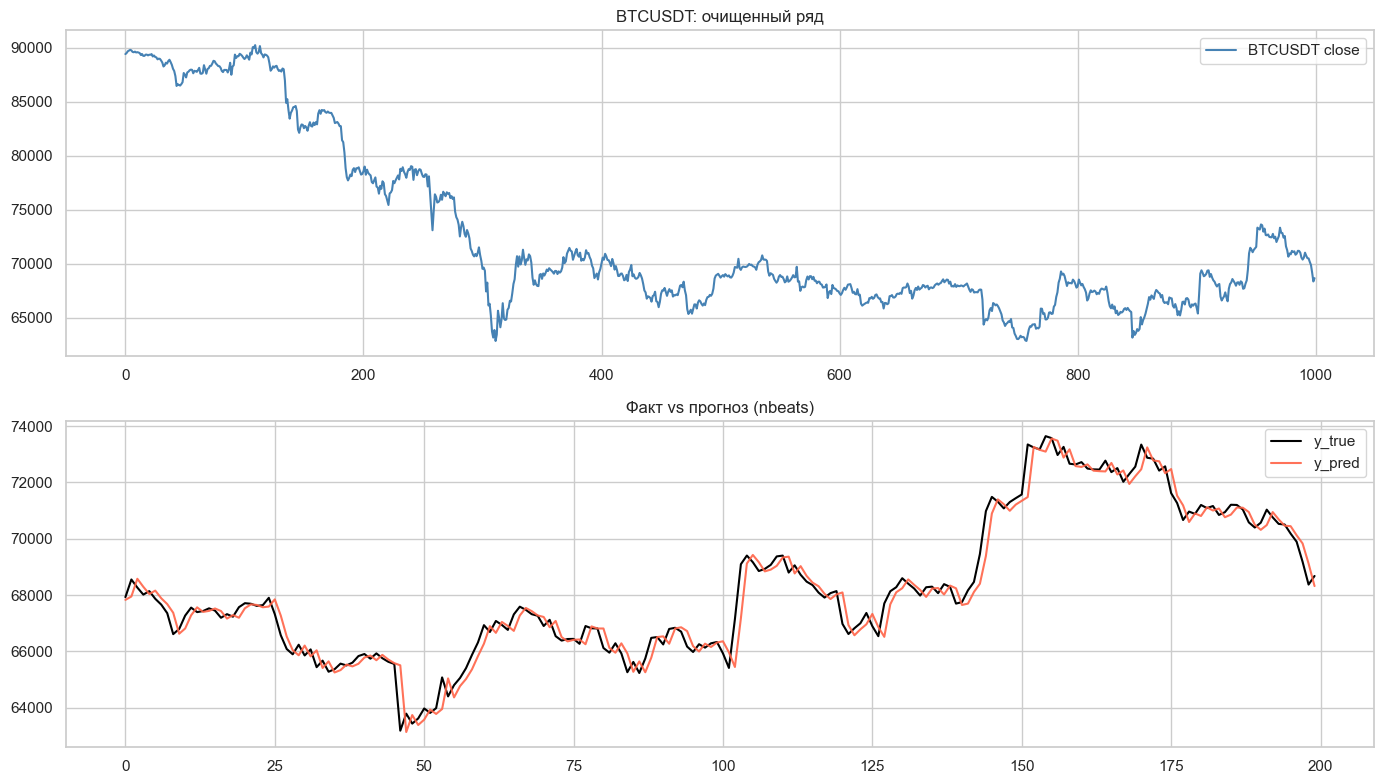

In [52]:
# 3.7) Модель N-BEATS (5-я модель) + native GridSearchCV
RUN_MODEL = 'nbeats'

NBEATS_PARAM_GRID = {
    'context_len': [120, 168],
    'n_blocks': [3, 4],
    'layers': [3, 4],
    'layer_size': [192, 256],
    'epochs': [16, 24],
    'batch_size': [128],
    'lr': [6e-4, 1e-3],
}
NBEATS_CV_SPLITS = 3

nbeats_best_params, nbeats_cv_df, model_metrics, pred_df, nbeats_split_info = run_nbeats_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=NBEATS_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=NBEATS_CV_SPLITS,
    scoring='MAE',
    use_cuda=True,
    n_jobs=1,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print('NBEATS split info:', nbeats_split_info)
print('NBEATS best params:', nbeats_best_params)
display(nbeats_cv_df.head(20))
print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

LSTM chunked CV: use_cuda=True, n_jobs принудительно установлен в 1 (безопасный режим для GPU).
LSTM chunked CV: points=29839 | folds=10 | combinations=64 | scoring=MAE | n_jobs=1
LSTM chunked CV: 1/64 | MAE=191.722129 +- 108.531756 | folds=10
LSTM chunked CV: 2/64 | MAE=191.675299 +- 108.915643 | folds=10
LSTM chunked CV: 3/64 | MAE=191.639167 +- 108.730420 | folds=10
LSTM chunked CV: 4/64 | MAE=192.010381 +- 108.819421 | folds=10
LSTM chunked CV: 5/64 | MAE=191.514009 +- 108.644579 | folds=10
LSTM chunked CV: 6/64 | MAE=191.780974 +- 108.650007 | folds=10
LSTM chunked CV: 7/64 | MAE=191.700819 +- 108.722679 | folds=10
LSTM chunked CV: 8/64 | MAE=191.923524 +- 108.856147 | folds=10
LSTM chunked CV: 9/64 | MAE=191.278917 +- 108.316378 | folds=10
LSTM chunked CV: 10/64 | MAE=192.253168 +- 109.107620 | folds=10
LSTM chunked CV: 11/64 | MAE=191.852096 +- 108.797473 | folds=10
LSTM chunked CV: 12/64 | MAE=192.014613 +- 108.938533 | folds=10
LSTM chunked CV: 13/64 | MAE=191.622874 +- 108.55

,chunk,chunk_points,train_points,val_points
0,1,2984,2387,597
1,2,2984,2387,597
2,3,2984,2387,597
3,4,2984,2387,597
4,5,2984,2387,597
5,6,2984,2387,597
6,7,2984,2387,597
7,8,2984,2387,597
8,9,2984,2387,597
9,10,2983,2386,597



Топ комбинаций по chunked CV:


,combination,context_len,hidden_size,num_layers,dropout,epochs,batch_size,lr,score,score_std,MAE,RMSE,MAPE,folds_used,error
0,9,72,96,2,0.00,16,32,0.0006,191.278917,108.316378,191.278917,283.990929,0.293793,10,
1,5,72,96,1,0.05,16,32,0.0006,191.514009,108.644579,191.514009,284.263412,0.293861,10,
2,21,72,128,1,0.05,16,32,0.0006,191.522298,108.363123,191.522298,284.159478,0.294123,10,
3,14,72,96,2,0.05,16,32,0.0010,191.535961,108.643206,191.535961,284.292731,0.293893,10,
4,22,72,128,1,0.05,16,32,0.0010,191.538981,108.456555,191.538981,284.312596,0.293995,10,
5,35,120,96,1,0.00,24,32,0.0006,191.562327,108.397347,191.562327,284.283320,0.294102,10,
6,33,120,96,1,0.00,16,32,0.0006,191.569130,108.773157,191.569130,284.469316,0.294003,10,
7,47,120,96,2,0.05,24,32,0.0006,191.595206,108.671944,191.595206,284.217795,0.294069,10,
8,25,72,128,2,0.00,16,32,0.0006,191.609793,108.501372,191.609793,284.220774,0.294330,10,
9,13,72,96,2,0.05,16,32,0.0006,191.622874,108.552020,191.622874,284.423569,0.294119,10,


LSTM device: cuda
LSTM train: 0%
LSTM train: 6% | val_loss=0.31856
LSTM train: 12% | val_loss=0.31641
LSTM train: 18% | val_loss=0.31641
LSTM train: 25% | val_loss=0.31641
LSTM train: 31% | val_loss=0.31641
LSTM train: 37% | val_loss=0.31641
LSTM early stop: epoch=6
LSTM infer: 5%
LSTM infer: 10%
LSTM infer: 15%
LSTM infer: 20%
LSTM infer: 25%
LSTM infer: 30%
LSTM infer: 35%
LSTM infer: 40%
LSTM infer: 45%
LSTM infer: 50%
LSTM infer: 55%
LSTM infer: 60%
LSTM infer: 65%
LSTM infer: 70%
LSTM infer: 75%
LSTM infer: 80%
LSTM infer: 85%
LSTM infer: 90%
LSTM infer: 95%
LSTM infer: 100%
SYMBOL=BTCUSDT | MODEL=lstm
Metrics: {'MAE': 288.8037450317295, 'RMSE': 434.79059153932235, 'MAPE': 0.3003933177678176}


,y_true,y_pred
0,108314.8,108015.629400
1,108661.3,108290.593493
2,108458.0,108628.286431
3,108449.9,108454.941123
4,108466.6,108441.854388


,y_true,y_pred
5963,70760.4,71015.274915
5964,70528.7,70775.497502
5965,70506.8,70540.757007
5966,70183.7,70513.716630
5967,69996.5,70208.470039


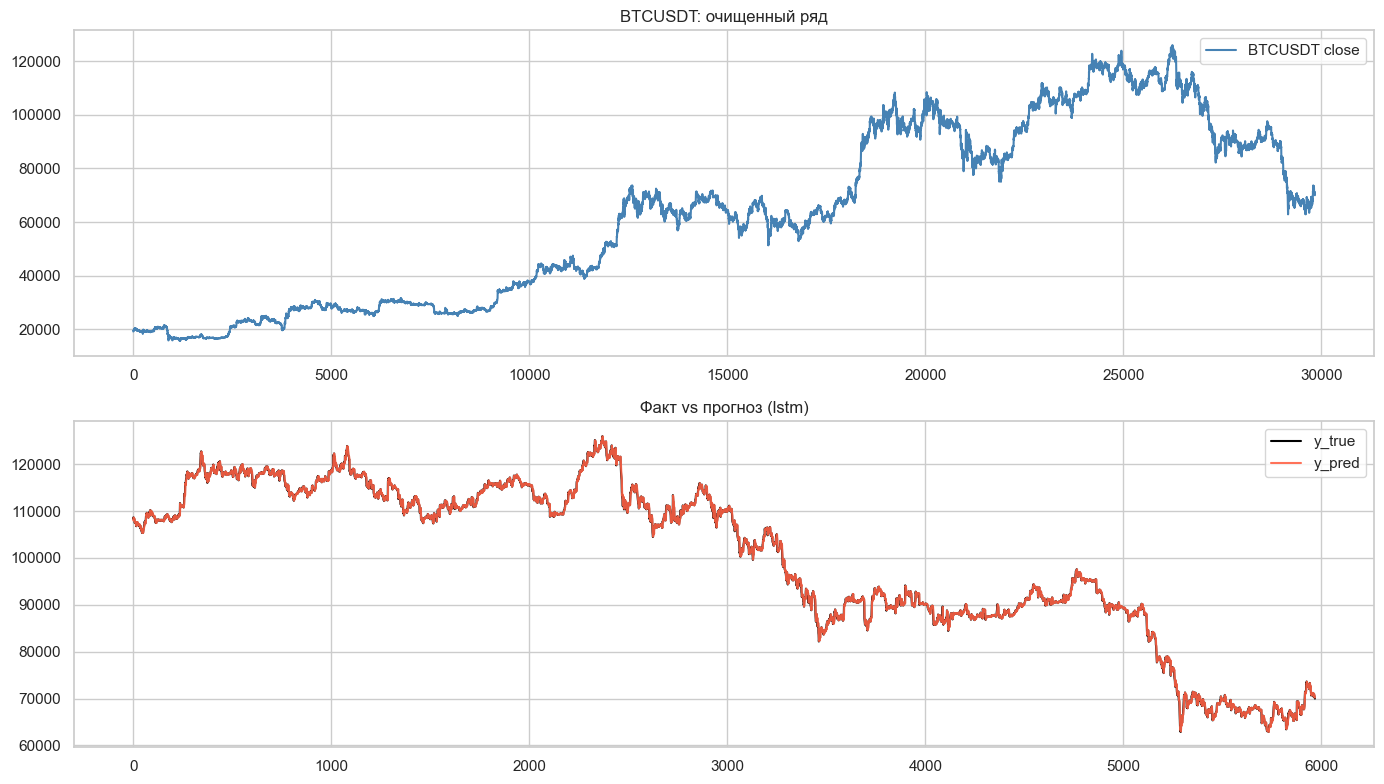

In [ ]:
# 3.9) Модель LSTM (6-я модель) + native sklearn GridSearchCV
RUN_MODEL = 'lstm'

LSTM_SCORING = 'MAE'
LSTM_GRID_N_JOBS = 1  # для одной GPU безопасно оставлять 1
LSTM_CV_SPLITS = 5

# GridSearchCV перебирает все комбинации (ParameterGrid)
LSTM_PARAM_GRID = {
    'context_len': [72, 120],
    'hidden_size': [96, 128],
    'num_layers': [1, 2],
    'dropout': [0.0, 0.05],
    'epochs': [16, 24],
    'batch_size': [32],
    'lr': [6e-4, 1e-3],
}

best_params, lstm_cv_df, model_metrics, pred_df, split_info = run_lstm_gridsearchcv_native_pipeline(
    full_series=full,
    param_grid=LSTM_PARAM_GRID,
    test_ratio=CONFIG.test_ratio,
    n_splits=LSTM_CV_SPLITS,
    scoring=LSTM_SCORING,
    use_cuda=True,
    n_jobs=LSTM_GRID_N_JOBS,
)

print('LSTM split info:', split_info)
print('LSTM best params:', best_params)
print('\nТоп комбинаций по GridSearchCV:')
display(lstm_cv_df.head(20))

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

print(f'SYMBOL={RUN_SYMBOL} | MODEL={RUN_MODEL}')
print('Metrics:', model_metrics)
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

In [ ]:
# 8.1) 100 случайных недельных датасетов с Bybit: проверка ВСЕХ алгоритмов
import numpy as np
import pandas as pd
import importlib
import os
import experiment_blocks as _exp

# подхватываем свежие правки (duration_sec и параллельный запуск)
_exp = importlib.reload(_exp)
run_weekly_random_validation = _exp.run_weekly_random_validation

N_WEEKS_REQUESTED = 100
CPU_COUNT = int(os.cpu_count() or 8)
PARALLEL_WORKERS = min(N_WEEKS_REQUESTED, max(8, min(32, CPU_COUNT * 2)))
SARIMA_MAX_CONCURRENCY = max(1, min(4, CPU_COUNT // 2))

weekly_metrics_df, summary, weeks_info_df, weekly_path, summary_path, weeks_info_path = run_weekly_random_validation(
    processor=processor,
    config=CONFIG,
    output_dir=OUTPUT_DIR,
    run_symbol=RUN_SYMBOL,
    run_naive=run_naive,
    run_arima=run_arima,
    run_sarima=run_sarima,
    run_nbeats=run_nbeats,
    run_lstm=run_lstm,
    arima_order=ARIMA_ORDER,
    sarima_order=SARIMA_ORDER,
    sarima_seasonal_order=SARIMA_SEASONAL_ORDER,
    run_ast_fn=run_ast_astmain_style,
    week_hours=7 * 24,
    n_weeks=N_WEEKS_REQUESTED,
    max_random_years_back=4,
    max_fetch_attempts_per_week=20,
    parallel_workers=PARALLEL_WORKERS,
    sarima_refit_every=168,   # быстрый профиль SARIMA для weekly-бенчмарка
    sarima_fit_window=336,
    sarima_maxiter=15,
    sarima_max_concurrency=SARIMA_MAX_CONCURRENCY,
 )

def _weekly_with_score(df: pd.DataFrame, metric_col: str = 'MAE'):
    work = (
        df.copy()
        .sort_values(['week', metric_col, 'model'], na_position='last')
        .reset_index(drop=True)
    )

    if 'duration_sec' not in work.columns:
        work['duration_sec'] = np.nan

    work['color_tag'] = 'orange'
    work['score'] = 1

    for _week_value, idxs in work.groupby('week', sort=True).groups.items():
        week_rows = work.loc[list(idxs)]
        valid = week_rows[week_rows[metric_col].notna()].sort_values(metric_col)
        if len(valid) == 0:
            continue

        best_metric = float(valid.iloc[0][metric_col])
        ranked_indices = list(valid.index)

        for rank_pos, ridx in enumerate(ranked_indices, start=1):
            cur_metric = float(work.loc[ridx, metric_col])
            worse_ratio = (cur_metric / best_metric) if best_metric > 1e-12 else np.inf

            if worse_ratio >= 2.0:
                work.loc[ridx, 'color_tag'] = 'red'
                work.loc[ridx, 'score'] = 0
            elif rank_pos == 1:
                work.loc[ridx, 'color_tag'] = 'green'
                work.loc[ridx, 'score'] = 3
            elif worse_ratio <= 1.10:
                work.loc[ridx, 'color_tag'] = 'yellow'
                work.loc[ridx, 'score'] = 2
            else:
                work.loc[ridx, 'color_tag'] = 'orange'
                work.loc[ridx, 'score'] = 1

        for ridx in week_rows.index:
            if pd.isna(work.loc[ridx, metric_col]):
                work.loc[ridx, 'color_tag'] = 'gray'
                work.loc[ridx, 'score'] = 0

    return work

def _weekly_style_with_dividers(scored_df: pd.DataFrame):
    row_styles = {i: '' for i in scored_df.index}
    color_map = {
        'green': 'background-color: #7CFC00; color: black',
        'yellow': 'background-color: #FFD700; color: black',
        'orange': 'background-color: #FFA500; color: black',
        'red': 'background-color: #ff6b6b; color: black',
        'gray': 'background-color: #D3D3D3; color: black',
    }

    def _append_style(base: str, extra: str) -> str:
        base = (base or '').strip()
        if not base:
            return extra
        if base.endswith(';'):
            return f"{base} {extra}"
        return f"{base}; {extra}"

    for idx, row in scored_df.iterrows():
        row_styles[idx] = _append_style(row_styles[idx], color_map.get(row['color_tag'], ''))

    for _week_value, idxs in scored_df.groupby('week', sort=True).groups.items():
        last_idx = int(max(idxs))
        row_styles[last_idx] = _append_style(
            row_styles.get(last_idx, ''),
            'border-bottom: 3px solid #444'
        )

    return scored_df.style.apply(
        lambda row: [row_styles.get(row.name, '') for _ in row.index],
        axis=1,
    )

def _build_model_ranking(scored_df: pd.DataFrame, summary_df: pd.DataFrame):
    rank_input = scored_df.copy()
    rank_input['green_count'] = (rank_input['color_tag'] == 'green').astype(int)
    rank_input['red_count'] = (rank_input['color_tag'] == 'red').astype(int)

    rank_df = (
        rank_input.groupby('model', as_index=False)
        .agg(
            points=('score', 'sum'),
            green_count=('green_count', 'sum'),
            red_count=('red_count', 'sum'),
            avg_duration_sec=('duration_sec', 'mean'),
            total_duration_sec=('duration_sec', 'sum'),
            weeks_count=('week', 'nunique'),
        )
        .sort_values(['points', 'green_count', 'red_count', 'avg_duration_sec'], ascending=[False, False, True, True])
        .reset_index(drop=True)
    )

    summary_plus = summary_df.merge(rank_df, on='model', how='left')
    return rank_df, summary_plus

scored_weekly_df = _weekly_with_score(weekly_metrics_df, metric_col='MAE')
styled_weekly = _weekly_style_with_dividers(scored_weekly_df)
model_ranking_df, summary_with_rank_df = _build_model_ranking(scored_weekly_df, summary)

max_points = int(N_WEEKS_REQUESTED * 3)

print('\nСохранено:')
print(weekly_path.resolve())
print(summary_path.resolve())
print(weeks_info_path.resolve())
print(f'Параллельный профиль: workers={PARALLEL_WORKERS}, sarima_max_concurrency={SARIMA_MAX_CONCURRENCY}')
print('\nЛегенда цветов (по каждой неделе, метрика MAE):')
print('🟩 лучшая | 🟨 в пределах +10% от лучшей | 🟧 остальные | 🟥 хуже лучшей на 100%+')
print('Границы между пятёрками моделей выделены толстой линией.')
print('Баллы: 🟥=0, 🟧=1, 🟨=2, 🟩=3')
print(f'Итог по {N_WEEKS_REQUESTED} неделям: 0 = очень плохо, {max_points} = очень хорошо')

print('\nВыбранные случайные недели:')
display(weeks_info_df)

print('\nWeekly-детализация (цветовая + баллы):')
display(styled_weekly)

print('\nРейтинг моделей по баллам:')
display(model_ranking_df)

print('\nСредние метрики + баллы + время обучения:')
display(summary_with_rank_df)

Проверяем модели: ['naive', 'arima', 'sarima', 'ast', 'nbeats', 'lstm']
Скачиваем 100 случайных недельных датасетов для BTCUSDT ...
Параллельный режим: 32 воркеров | SARIMA одновременно: 4
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=62
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
torch=2.5.1+cu121 | torch.cuda=12.1 | cuda_available=True
CUDA device: NVIDIA GeForce RTX 4080
AST device: cuda | AMP=True | GAN=False | train_windows=63
AST: 0%
AST: 0%
AST: 0%
AST: 0%
AST: 16% | lr=0.000467AST: 16% | lr=0.000467
AST: 16% | lr=0.000467

AST: 16% | lr=0.000467
AST: 33% | lr=0.000378
AST: 33% | lr=0.000378
AST: 33% | lr=0.000378
AS

,week,start_ts,end_ts,raw_points,clean_points
0,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,168,168
1,2,2024-01-26 06:00:00+00:00,2024-02-02 05:00:00+00:00,168,168
2,3,2025-07-01 21:00:00+00:00,2025-07-08 20:00:00+00:00,168,168
3,4,2022-10-15 09:00:00+00:00,2022-10-22 08:00:00+00:00,168,168
4,5,2025-07-12 07:00:00+00:00,2025-07-19 06:00:00+00:00,168,168
...,...,...,...,...,...
95,96,2022-05-31 22:00:00+00:00,2022-06-07 21:00:00+00:00,168,166
96,97,2024-02-02 03:00:00+00:00,2024-02-09 02:00:00+00:00,168,168
97,98,2022-12-26 08:00:00+00:00,2023-01-02 07:00:00+00:00,168,168
98,99,2025-08-30 15:00:00+00:00,2025-09-06 14:00:00+00:00,168,166



Weekly-детализация (цветовая + баллы):


,symbol,week,start_ts,end_ts,model,n_points,MAE,RMSE,MAPE,duration_sec,color_tag,score
0,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,naive,168,233.567647,313.118285,0.207420,0.000174,green,3
1,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,nbeats,168,236.722456,312.769101,0.210222,6.657074,yellow,2
2,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,arima,168,237.767739,318.747298,0.211122,3.082757,yellow,2
3,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,ast,168,392.819417,470.296791,0.348718,5.177074,orange,1
4,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,sarima,168,408.894407,514.673684,0.362981,2.562211,orange,1
5,BTCUSDT,1,2025-09-18 09:00:00+00:00,2025-09-25 08:00:00+00:00,lstm,168,544.737572,701.130276,0.485209,3.448397,red,0
6,BTCUSDT,2,2024-01-26 06:00:00+00:00,2024-02-02 05:00:00+00:00,naive,168,152.323529,217.580803,0.357778,0.000172,green,3
7,BTCUSDT,2,2024-01-26 06:00:00+00:00,2024-02-02 05:00:00+00:00,arima,168,155.643866,218.861279,0.365580,3.114795,yellow,2
8,BTCUSDT,2,2024-01-26 06:00:00+00:00,2024-02-02 05:00:00+00:00,nbeats,168,157.980383,220.958808,0.370846,6.801034,yellow,2
9,BTCUSDT,2,2024-01-26 06:00:00+00:00,2024-02-02 05:00:00+00:00,sarima,168,168.046614,248.325875,0.394850,5.274094,orange,1



Рейтинг моделей по баллам:


,model,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,naive,255,56,0,0.000223,0.022283,100
1,arima,225,34,2,1.835991,183.599114,100
2,nbeats,158,8,5,8.528605,852.860458,100
3,sarima,97,1,10,8.881426,888.142604,100
4,ast,29,1,74,7.564517,756.451711,100
5,lstm,15,0,86,4.762936,476.293553,100



Средние метрики + баллы + время обучения:


,model,MAE,RMSE,MAPE,points,green_count,red_count,avg_duration_sec,total_duration_sec,weeks_count
0,naive,175.522709,243.806852,0.311436,255,56,0,0.000223,0.022283,100
1,arima,191.571659,265.831465,0.350812,225,34,2,1.835991,183.599114,100
2,nbeats,211.843475,279.864615,0.376731,158,8,5,8.528605,852.860458,100
3,sarima,250.326537,337.690108,0.446240,97,1,10,8.881426,888.142604,100
4,ast,830.477505,908.638410,1.759568,29,1,74,7.564517,756.451711,100
5,lstm,861.399147,956.352934,1.744738,15,0,86,4.762936,476.293553,100


## 9) Сохранение артефактов и экспорт

Сохраняем предсказания и метрики, чтобы можно было быстро сравнивать запуски.

In [ ]:
symbol_for_save = RUN_SYMBOL if 'RUN_SYMBOL' in globals() else 'UNKNOWN'

if 'ALL_RESULTS' not in globals() or len(ALL_RESULTS) == 0:
    raise RuntimeError('Нет результатов. Сначала запусти модельные ячейки naive, arima, sarima, ast, nbeats, lstm.')

# Подхватываем последний запуск модели, если она ещё не в реестре
if 'RUN_MODEL' in globals() and 'model_metrics' in globals() and 'pred_df' in globals() and RUN_MODEL not in ALL_RESULTS:
    ALL_RESULTS[RUN_MODEL] = {
        'metrics': model_metrics,
        'pred_df': pred_df.copy(),
        'symbol': symbol_for_save,
    }

run_dir, metrics_path, metrics_df = export_all_results(
    output_dir=OUTPUT_DIR,
    symbol=symbol_for_save,
    full_series=full,
    all_results=ALL_RESULTS,
 )

print('Сохранено:')
print(run_dir.resolve())
print(metrics_path.resolve())
print('\nСводная таблица метрик:')
display(metrics_df)

missing_models = [m for m in ['naive', 'arima', 'sarima', 'ast', 'nbeats', 'lstm'] if m not in ALL_RESULTS]
if missing_models:
    print(f"\nНе хватает результатов моделей: {missing_models}. Запусти соответствующие модельные ячейки.")

Сохранено:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260306_113640
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_all_models_20260306_113640\BTCUSDT_all_models_metrics.csv

Сводная таблица метрик:


,symbol,model,MAE,RMSE,MAPE
0,BTCUSDT,naive,280.401338,399.365998,0.414102
1,BTCUSDT,arima,281.351831,399.323095,0.415457
2,BTCUSDT,sarima,287.804112,404.989979,0.424914
3,BTCUSDT,nbeats,388.637195,498.415356,0.573386
4,BTCUSDT,lstm,794.232044,954.029431,1.186009
5,BTCUSDT,ast,961.735865,1058.394906,1.423769


In [ ]:
import importlib, model_baselines, inspect
print('module file:', model_baselines.__file__)
print('has run_sarima:', hasattr(model_baselines, 'run_sarima'))
print('symbols:', [s for s in dir(model_baselines) if s.startswith('run_')])
importlib.reload(model_baselines)
print('after reload has run_sarima:', hasattr(model_baselines, 'run_sarima'))

module file: c:\Users\zzz20\ModelLine\model_baselines.py
has run_sarima: True
symbols: ['run_arima', 'run_lstm', 'run_naive', 'run_nbeats', 'run_sarima']
after reload has run_sarima: True
